In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error

# Read training data
train_data = pd.read_csv("data/bike_train.csv")
print(train_data.head())

              datetime  season  holiday  workingday  weather      temp  \
0   2012-07-15 7:00:00       3        0           0        1  28.70000   
1  2012-08-14 15:00:00       3        0           1        1  33.62000   
2   2011-02-06 6:00:00       1        0           0        1  10.66000   
3  2012-05-06 17:00:02       2        0           0        2  26.42506   
4   2012-01-09 2:00:00       1        0           1        1   9.84000   

       atemp  humidity  windspeed  casual  registered  count  
0  33.335000        79   6.003200      17          30     47  
1  37.880000        46  15.001300      84         199    283  
2  12.880000        60  15.001300       0           1      1  
3  30.566166        61   9.512288     198         330    531  
4  12.120000        56   8.998100       2           3      5  


In [2]:
# Read test data
test_input_file = "data/bike_test.csv"
test_data = pd.read_csv(test_input_file)
print(test_data.head())

           datetime  season  holiday  workingday  weather       temp  \
0   05-06-2012 5:00       2        0           1        3  19.680000   
1  19-03-2011 19:00       1        0           0        1  18.040000   
2   02-04-2012 6:00       2        0           1        1  13.885038   
3  13-07-2012 20:00       3        0           1        1  30.340000   
4  09-11-2011 19:00       4        0           1        1  18.040000   

      atemp  humidity  windspeed  
0  23.48500        82   11.00140  
1  21.97000        33   19.00120  
2  16.24664        68   29.52646  
3  33.33500        48    8.99810  
4  21.97000        72    7.00150  


## Q1: Examine dataset size, missing values, and feature types

In [3]:
# Q1: Examine dataset size, missing values, and feature types
print("=" * 50)
print("TRAINING DATA")
print("=" * 50)
print(f"Dataset size: {train_data.shape[0]} rows, {train_data.shape[1]} columns")
print(f"\nMissing values:\n{train_data.isnull().sum()}")
print(f"\nFeature types:\n{train_data.dtypes}")
print(f"\nBasic statistics:\n{train_data.describe()}")

print("\n" + "=" * 50)
print("TEST DATA")
print("=" * 50)
print(f"Dataset size: {test_data.shape[0]} rows, {test_data.shape[1]} columns")
print(f"\nMissing values:\n{test_data.isnull().sum()}")

# IMPORTANT: Note that 'casual' and 'registered' are in train but NOT in test
print("\n" + "=" * 50)
print("IMPORTANT OBSERVATION")
print("=" * 50)
print(f"Train columns: {list(train_data.columns)}")
print(f"Test columns:  {list(test_data.columns)}")
print("\n'casual' and 'registered' are NOT available in test data.")
print("count = casual + registered, so using them as features would cause DATA LEAKAGE.")

TRAINING DATA
Dataset size: 10450 rows, 12 columns

Missing values:
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

Feature types:
datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object

Basic statistics:
             season       holiday    workingday       weather          temp  \
count  10450.000000  10450.000000  10450.000000  10450.000000  10450.000000   
mean       2.507943      0.028804      0.675694      1.413876     20.191700   
std        1.116946      0.167263      0.468137      0.632258      7.792683   
min        1.000000      0.000000      0.000000      1.000000      0.820000   
25%        2.000000

## Q2: Visualize relationships between key features and the target variable (count)

We extract `hour` from `datetime` first, then visualize key relationships.

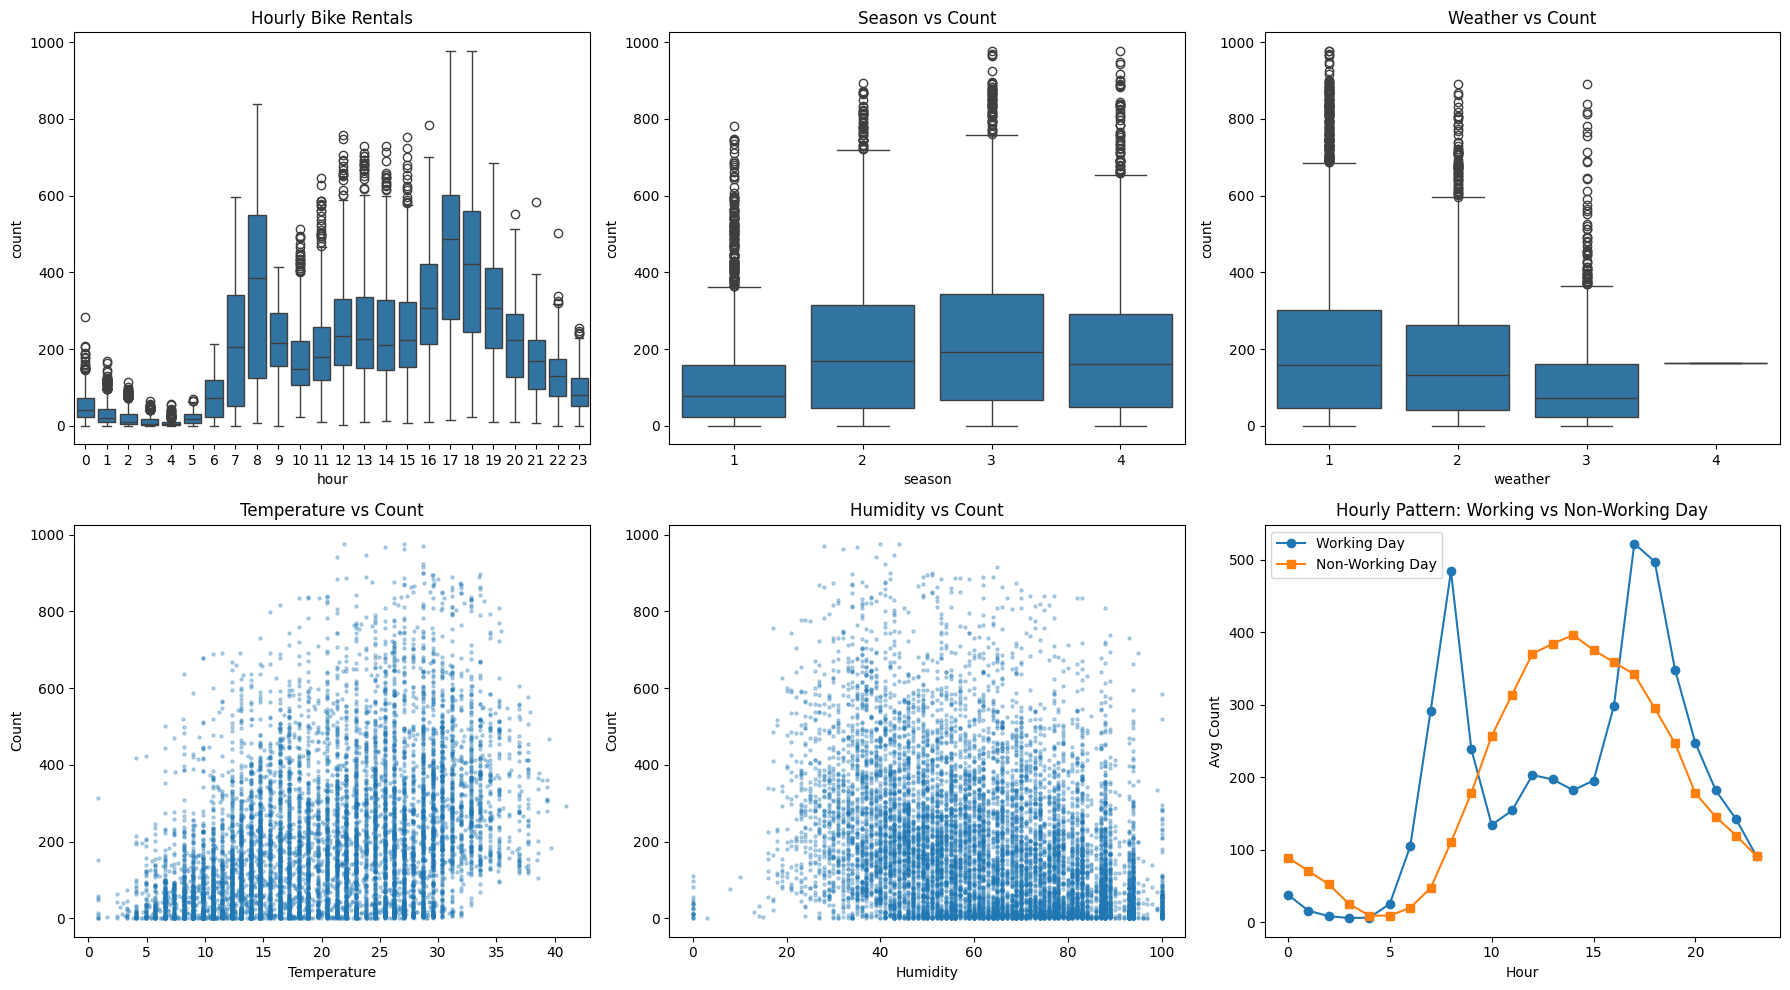

In [4]:
# Extract hour for visualization (full feature engineering done later)
train_data["hour"] = pd.to_datetime(train_data["datetime"]).dt.hour

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Hour vs Count - most important relationship
sns.boxplot(x="hour", y="count", data=train_data, ax=axes[0, 0])
axes[0, 0].set_title("Hourly Bike Rentals")

# Season vs Count
sns.boxplot(x="season", y="count", data=train_data, ax=axes[0, 1])
axes[0, 1].set_title("Season vs Count")

# Weather vs Count
sns.boxplot(x="weather", y="count", data=train_data, ax=axes[0, 2])
axes[0, 2].set_title("Weather vs Count")

# Temp vs Count
axes[1, 0].scatter(train_data["temp"], train_data["count"], alpha=0.3, s=5)
axes[1, 0].set_xlabel("Temperature")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Temperature vs Count")

# Humidity vs Count
axes[1, 1].scatter(train_data["humidity"], train_data["count"], alpha=0.3, s=5)
axes[1, 1].set_xlabel("Humidity")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Humidity vs Count")

# Working Day vs Count by Hour
workday = train_data[train_data["workingday"] == 1].groupby("hour")["count"].mean()
nonwork = train_data[train_data["workingday"] == 0].groupby("hour")["count"].mean()
axes[1, 2].plot(workday.index, workday.values, label="Working Day", marker="o")
axes[1, 2].plot(nonwork.index, nonwork.values, label="Non-Working Day", marker="s")
axes[1, 2].set_xlabel("Hour")
axes[1, 2].set_ylabel("Avg Count")
axes[1, 2].set_title("Hourly Pattern: Working vs Non-Working Day")
axes[1, 2].legend()

plt.tight_layout()
plt.show()

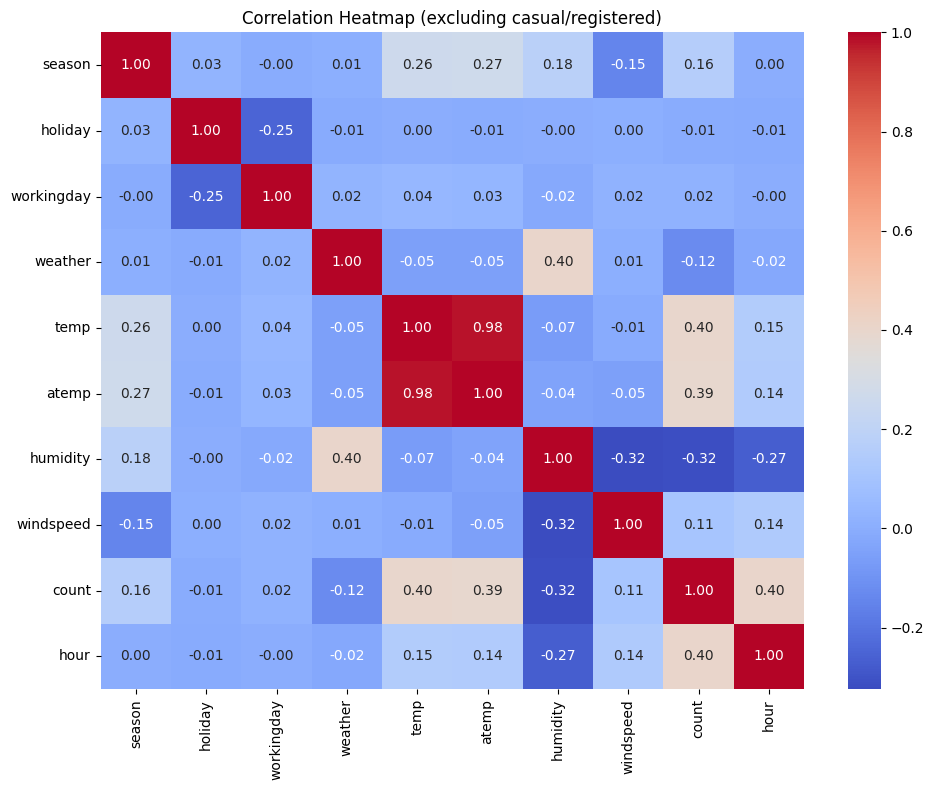


Correlation with 'count' (absolute, sorted):
count         1.000000
hour          0.404188
temp          0.396451
atemp         0.390642
humidity      0.316607
season        0.160333
weather       0.124402
windspeed     0.105318
workingday    0.017361
holiday       0.005615
Name: count, dtype: float64


In [5]:
# Correlation heatmap (excluding casual, registered which leak the target)
cols_for_corr = [c for c in train_data.columns if c not in ["datetime", "casual", "registered"]]
correlation_matrix = train_data[cols_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (excluding casual/registered)")
plt.tight_layout()
plt.show()

# Correlation with target
print("\nCorrelation with 'count' (absolute, sorted):")
print(correlation_matrix["count"].abs().sort_values(ascending=False))

## Q3: Which variables are likely to be most informative?

From the correlation heatmap and visualizations:

1. **`hour`** — Strongest predictor. Bike demand has clear peaks at 8 AM and 5-6 PM (commute hours) on workdays, and midday peaks on weekends.
2. **`temp` / `atemp`** — Positive correlation with count. Warmer weather → more rentals.
3. **`season`** — Summer/Fall have higher demand than Winter/Spring.
4. **`humidity`** — Negative correlation. Higher humidity reduces rentals.
5. **`workingday`** — Affects the *shape* of hourly demand (bimodal on workdays vs unimodal on weekends).
6. **`weather`** — Clear weather → more rentals; heavy rain → fewer.
7. **`windspeed`** — Weak negative correlation.

**Critical note:** `casual` and `registered` are NOT used as features because:
- `count = casual + registered` (they *are* the target, split into components)
- They are NOT available in the test dataset
- Using them would cause **data leakage** and artificially inflate model performance

## Q4: Feature Engineering

We derive new features from `datetime` and encode categorical variables to help the model capture nonlinear patterns.

**Features engineered:**
- **`hour`**: Hour of day (0-23) — captures daily demand patterns
- **`month`**: Month (1-12) — captures seasonal trends
- **`weekday`**: Day of week (0=Mon, 6=Sun) — weekday vs weekend effects
- **`year`**: Year (2011/2012) — bike sharing grew over time
- **One-hot encoding of `season`** (4 categories) — categorical, not ordinal
- **One-hot encoding of `weather`** (4 categories) — categorical, not ordinal
- **`hour_workday`**: Interaction of hour × workingday — captures distinct commute vs leisure patterns

In [6]:
def engineer_features(df):
    """Apply feature engineering to a dataframe (works for both train and test)."""
    df = df.copy()
    # Train data uses YYYY-MM-DD format, test data uses DD-MM-YYYY format
    # Use format="mixed" to let pandas infer per-element, with dayfirst for DD-MM-YYYY
    try:
        # Try ISO format first (train data: "2012-07-15 7:00:00")
        dt = pd.to_datetime(df["datetime"])
    except (ValueError, TypeError):
        # Fallback for test data: "05-06-2012 5:00" (DD-MM-YYYY)
        dt = pd.to_datetime(df["datetime"], dayfirst=True)

    # Time-based features
    df["hour"] = dt.dt.hour
    df["month"] = dt.dt.month
    df["weekday"] = dt.dt.weekday   # 0=Monday, 6=Sunday
    df["year"] = dt.dt.year

    # Interaction: hour × workingday (commute patterns differ)
    df["hour_workday"] = df["hour"] * df["workingday"]

    # scale temp and humidity to [0,1] range (helps some models) using MinMaxScaler
    # normalization didn't helped in this case.
    # scaler = MinMaxScaler()
    # df[["temp", "humidity"]] = scaler.fit_transform(df[["temp", "humidity"]])

    # One-hot encode season and weather (they are categorical, not ordinal)
    df = pd.get_dummies(df, columns=["holiday", "season", "weather", "hour_workday", "hour", "weekday", "month", "year"], drop_first=True, dtype=int)

    # Drop columns not useful for modeling
    df.drop(columns=["datetime"], inplace=True)

    return df

# Apply feature engineering
train_fe = engineer_features(train_data)

# Remove target-leaking columns (casual, registered) and separate target
y_full = train_fe["count"]

# remove 'casual', 'registered' (leaking), 'atemp' (redundant with temp), and 'humidity' (low correlation)
X_full = train_fe.drop(columns=["count", "casual", "registered", "atemp", "humidity"])

print("Engineered feature columns:")
print(list(X_full.columns))
print(f"\nShape: {X_full.shape}")
print(f"\nSample:\n{X_full.head()}")

Engineered feature columns:
['workingday', 'temp', 'windspeed', 'holiday_1', 'season_2', 'season_3', 'season_4', 'weather_2', 'weather_3', 'weather_4', 'hour_workday_1', 'hour_workday_2', 'hour_workday_3', 'hour_workday_4', 'hour_workday_5', 'hour_workday_6', 'hour_workday_7', 'hour_workday_8', 'hour_workday_9', 'hour_workday_10', 'hour_workday_11', 'hour_workday_12', 'hour_workday_13', 'hour_workday_14', 'hour_workday_15', 'hour_workday_16', 'hour_workday_17', 'hour_workday_18', 'hour_workday_19', 'hour_workday_20', 'hour_workday_21', 'hour_workday_22', 'hour_workday_23', 'hour_1', 'hour_2', 'hour_3', 'hour_4', 'hour_5', 'hour_6', 'hour_7', 'hour_8', 'hour_9', 'hour_10', 'hour_11', 'hour_12', 'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18', 'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10'

In [7]:
# RMSLE metric (as specified in the assignment)
def rmsle(y_true, y_pred):
    # Clip predictions to avoid log of negative values
    y_pred_clipped = np.clip(y_pred, 0, None)
    return np.sqrt(np.mean((np.log1p(y_pred_clipped) - np.log1p(y_true))**2))

# Regression Models

## Q5: Simple Linear Regression

In [8]:
# Q5: Split data and build a simple Linear Regression model
X_train, X_val, y_train, y_val = train_test_split(X_full, y_full, test_size=0.3, random_state=42)

# Model 1: Simple Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_val)
rmsle_lr = rmsle(y_val, y_pred_lr)
mse_lr = mean_squared_error(y_val, y_pred_lr)

print("Linear Regression Results:")
print(f"  RMSLE: {rmsle_lr:.4f}")
print(f"  RMSE:  {np.sqrt(mse_lr):.4f}")
print(f"  Negative predictions: {(y_pred_lr < 0).sum()} out of {len(y_pred_lr)}")

Linear Regression Results:
  RMSLE: 1.0464
  RMSE:  77.3836
  Negative predictions: 343 out of 3135


## Q6: Polynomial Features + Ridge and Lasso Regression

We extend the feature space with polynomial transformations and apply regularized regression to control overfitting.

In [9]:
# Q6: Polynomial features (degree 2) + Ridge and Lasso Regression

# Select features for polynomial expansion:
# - Continuous: temp, windspeed, workingday → quadratic effects (temp², etc.)
# - Hour dummies: interactions with temp/windspeed (e.g., hour_8 × temp) are crucial
# - Season/weather dummies: interactions with continuous features
# Remaining one-hot features (holiday, hour_workday, weekday, month, year) are kept as-is.
continuous_cols = [c for c in ['temp', 'windspeed', 'workingday'] if c in X_train.columns]
hour_dummy_cols = [c for c in X_train.columns if c.startswith('hour_') and not c.startswith('hour_workday')]
season_weather_cols = [c for c in X_train.columns if c.startswith(('season_', 'weather_'))]
poly_cols = continuous_cols + hour_dummy_cols + season_weather_cols
other_cols = [c for c in X_train.columns if c not in poly_cols]

# Scale features before polynomial expansion
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[poly_cols])
X_val_scaled = scaler.transform(X_val[poly_cols])

# Polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_expanded = poly.fit_transform(X_train_scaled)
X_val_poly_expanded = poly.transform(X_val_scaled)

# Combine polynomial features with remaining one-hot features
X_train_poly = np.hstack([X_train_poly_expanded, X_train[other_cols].values])
X_val_poly = np.hstack([X_val_poly_expanded, X_val[other_cols].values])
print(f"Feature count: {X_train_poly.shape[1]} ({X_train_poly_expanded.shape[1]} poly from {len(poly_cols)} features + {len(other_cols)} other)")

# Store results for comparison
results = []
results.append({"Model": "Linear Regression", "RMSLE": rmsle_lr, "RMSE": np.sqrt(mse_lr)})

# Model 2: Linear Regression on Polynomial features
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_lr_poly = lr_poly.predict(X_val_poly)
rmsle_lr_poly = rmsle(y_val, y_pred_lr_poly)
print(f"\nLinear Regression (Poly degree=2): RMSLE = {rmsle_lr_poly:.4f}")
results.append({"Model": "Linear Reg + Poly(2)", "RMSLE": rmsle_lr_poly, "RMSE": np.sqrt(mean_squared_error(y_val, y_pred_lr_poly))})

# Model 3 & 4: Ridge Regression with different alpha values
best_ridge_rmsle = float('inf')
best_ridge_alpha = None
best_ridge_model = None

print("\nRidge Regression (Poly degree=2) — tuning alpha:")
for alpha in [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 5000.0, 10000.0, 20000.0, 50000.0]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_poly, y_train)
    y_pred_ridge = ridge.predict(X_val_poly)
    r = rmsle(y_val, y_pred_ridge)
    print(f"  alpha={alpha:>9.2f}: RMSLE = {r:.4f}")
    if r < best_ridge_rmsle:
        best_ridge_rmsle = r
        best_ridge_alpha = alpha
        best_ridge_model = ridge

print(f"  Best Ridge: alpha={best_ridge_alpha}, RMSLE={best_ridge_rmsle:.4f}")
y_pred_best_ridge = best_ridge_model.predict(X_val_poly)
results.append({"Model": f"Ridge (alpha={best_ridge_alpha})", "RMSLE": best_ridge_rmsle,
                 "RMSE": np.sqrt(mean_squared_error(y_val, y_pred_best_ridge))})

# Model 5 & 6: Lasso Regression with different alpha values
best_lasso_rmsle = float('inf')
best_lasso_alpha = None
best_lasso_model = None

print("\nLasso Regression (Poly degree=2) — tuning alpha:")
for alpha in [0.1, 1.0, 3.0, 5.0, 7.0, 10.0, 50.0, 100.0]:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_poly, y_train)
    y_pred_lasso = lasso.predict(X_val_poly)
    r = rmsle(y_val, y_pred_lasso)
    n_nonzero = np.sum(lasso.coef_ != 0)
    print(f"  alpha={alpha:>7.2f}: RMSLE = {r:.4f} (non-zero coefficients: {n_nonzero})")
    if r < best_lasso_rmsle:
        best_lasso_rmsle = r
        best_lasso_alpha = alpha
        best_lasso_model = lasso

print(f"  Best Lasso: alpha={best_lasso_alpha}, RMSLE={best_lasso_rmsle:.4f}")
y_pred_best_lasso = best_lasso_model.predict(X_val_poly)
results.append({"Model": f"Lasso (alpha={best_lasso_alpha})", "RMSLE": best_lasso_rmsle,
                 "RMSE": np.sqrt(mean_squared_error(y_val, y_pred_best_lasso))})

Feature count: 602 (560 poly from 32 features + 42 other)

Linear Regression (Poly degree=2): RMSLE = 1.0913

Ridge Regression (Poly degree=2) — tuning alpha:
  alpha=     0.01: RMSLE = 1.0913
  alpha=     0.10: RMSLE = 1.0912
  alpha=     1.00: RMSLE = 1.0907
  alpha=    10.00: RMSLE = 1.0842
  alpha=   100.00: RMSLE = 1.0455
  alpha=  1000.00: RMSLE = 0.8965
  alpha=  5000.00: RMSLE = 0.7477
  alpha= 10000.00: RMSLE = 0.8024
  alpha= 20000.00: RMSLE = 0.9027
  alpha= 50000.00: RMSLE = 1.0461
  Best Ridge: alpha=5000.0, RMSLE=0.7477

Lasso Regression (Poly degree=2) — tuning alpha:
  alpha=   0.10: RMSLE = 1.0666 (non-zero coefficients: 242)
  alpha=   1.00: RMSLE = 1.0355 (non-zero coefficients: 154)
  alpha=   3.00: RMSLE = 0.9946 (non-zero coefficients: 76)
  alpha=   5.00: RMSLE = 0.9498 (non-zero coefficients: 57)
  alpha=   7.00: RMSLE = 0.9590 (non-zero coefficients: 46)
  alpha=  10.00: RMSLE = 0.9624 (non-zero coefficients: 41)
  alpha=  50.00: RMSLE = 1.1919 (non-zero coeffi

# Model Comparison and Interpretation

## Q7: Summary of all model results

In [10]:
# Q7: Model comparison table
results_df = pd.DataFrame(results)
results_df["RMSLE"] = results_df["RMSLE"].round(4)
results_df["RMSE"] = results_df["RMSE"].round(4)
results_df = results_df.sort_values("RMSLE")
results_df["Rank"] = range(1, len(results_df) + 1)

print("=" * 70)
print("MODEL COMPARISON TABLE")
print("=" * 70)
print(results_df[["Rank", "Model", "RMSLE", "RMSE"]].to_string(index=False))
print("=" * 70)

best_model_name = results_df.iloc[0]["Model"]
print(f"\nBest model: {best_model_name} (RMSLE = {results_df.iloc[0]['RMSLE']:.4f})")

MODEL COMPARISON TABLE
 Rank                Model  RMSLE    RMSE
    1 Ridge (alpha=5000.0) 0.7477 83.6188
    2    Lasso (alpha=5.0) 0.9498 79.1093
    3    Linear Regression 1.0464 77.3836
    4 Linear Reg + Poly(2) 1.0913 66.7851

Best model: Ridge (alpha=5000.0) (RMSLE = 0.7477)


## Q8: Residual plot for the best model

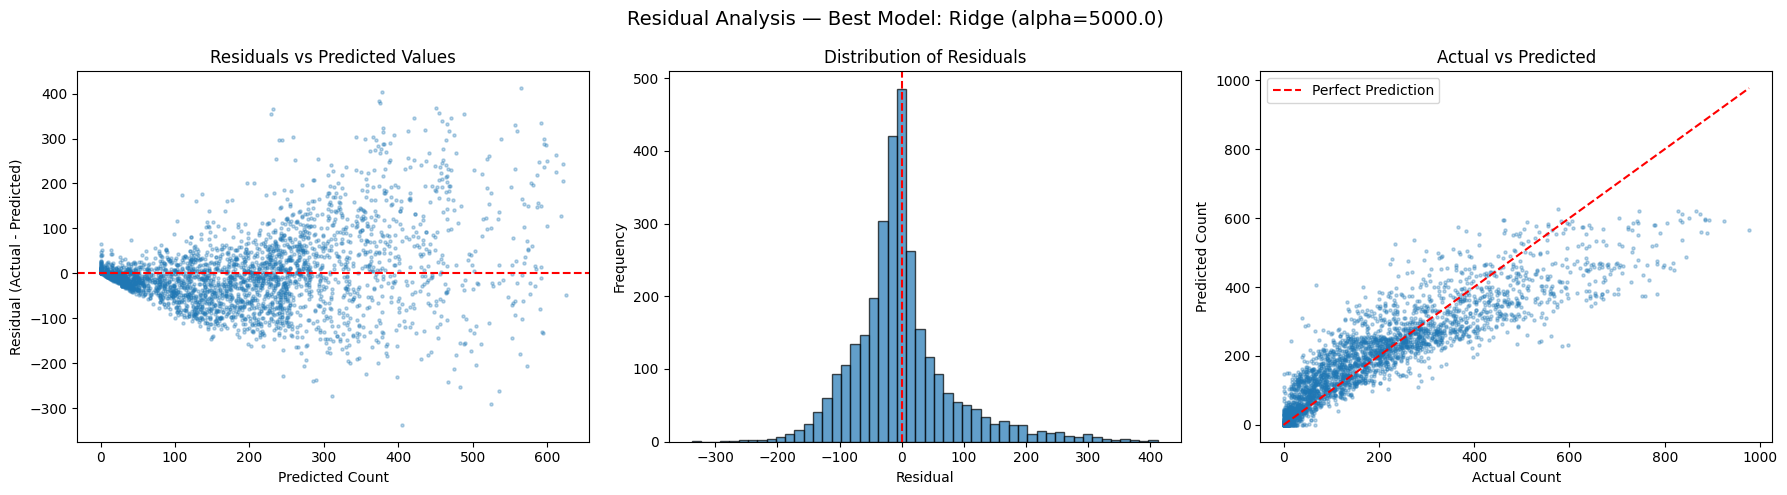

Residual Statistics:
  Mean: 0.03
  Std:  83.48
  Min:  -337.59
  Max:  412.21


In [11]:
# Q8: Residual plot for the best model
# Determine which polynomial model is best
if best_lasso_rmsle < best_ridge_rmsle:
    best_poly_model = best_lasso_model
    best_poly_name = f"Lasso (alpha={best_lasso_alpha})"
else:
    best_poly_model = best_ridge_model
    best_poly_name = f"Ridge (alpha={best_ridge_alpha})"

y_pred_best = best_poly_model.predict(X_val_poly)
y_pred_best_clipped = np.clip(y_pred_best, 0, None)
residuals = y_val.values - y_pred_best_clipped

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Residual Analysis — Best Model: {best_poly_name}", fontsize=14)

# Residuals vs Predicted
axes[0].scatter(y_pred_best_clipped, residuals, alpha=0.3, s=5)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel("Predicted Count")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs Predicted Values")

# Residual distribution
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Residuals")

# Actual vs Predicted
axes[2].scatter(y_val, y_pred_best_clipped, alpha=0.3, s=5)
max_val = max(y_val.max(), y_pred_best_clipped.max())
axes[2].plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')
axes[2].set_xlabel("Actual Count")
axes[2].set_ylabel("Predicted Count")
axes[2].set_title("Actual vs Predicted")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Residual Statistics:")
print(f"  Mean: {residuals.mean():.2f}")
print(f"  Std:  {residuals.std():.2f}")
print(f"  Min:  {residuals.min():.2f}")
print(f"  Max:  {residuals.max():.2f}")

## Q9: Why does the winning model perform better?

The **Ridge regression with polynomial features (degree 2)** outperforms plain Linear Regression because:

1. **Polynomial features capture nonlinear relationships**: Bike demand has strong nonlinear patterns — e.g., demand peaks at certain hours and drops sharply outside those windows. Degree-2 polynomials allow the model to learn quadratic and interaction effects (like `temp²` or `hour_8 × temp` — e.g., warm temperature matters most during peak commute hours).

2. **Selective polynomial expansion avoids feature explosion**: Naively applying polynomial features to all 74 engineered features would generate ~2,849 terms, making Lasso intractable. Instead, polynomial expansion was applied only to the 32 most meaningful features (temp, windspeed, workingday + 23 hour dummies + 3 season + 3 weather dummies), producing **602 features** — large enough to capture interactions but small enough to train in seconds.

3. **Regularization prevents overfitting**: With 602 polynomial features, there is a high risk of overfitting. Ridge (L2 penalty) shrinks all coefficients toward zero, preventing any single noisy interaction term from dominating. Without regularization, Linear Regression on the same polynomial features actually performs *worse* (RMSLE = 1.0913) due to overfitting.

4. **Ridge outperforms Lasso here**: Ridge (RMSLE = 0.7477, alpha=5000) significantly beats Lasso (RMSLE = 0.9498, alpha=5). Since our engineered features are mostly already sparse one-hot dummies, Lasso's sparsity-inducing property is less valuable — many genuinely useful features get zeroed out at larger alphas. Ridge retains all features with appropriately shrunk weights.

5. **Simple Linear Regression is too rigid**: It assumes a purely linear relationship between each feature and the target. Since bike demand is inherently nonlinear (hour-of-day effects, temperature curves), plain linear regression underfits and achieves only RMSLE = 1.0464.

6. **Strong regularization is needed**: The best alpha values are large (5000 for Ridge, 5 for Lasso), confirming that aggressive regularization of the 602-feature polynomial space is critical to prevent overfitting.

# Reflection Questions

## Q10: Why does RMSLE penalize under-predictions more gently than RMSE?

RMSLE operates in log-space: $\text{RMSLE} = \sqrt{\frac{1}{n}\sum(\log(p_i+1) - \log(a_i+1))^2}$

- The logarithm compresses large values and expands small values. So an error of 100 vs 200 (absolute difference = 100) is treated the same as 10 vs 20 (absolute difference = 10), because both have the same log-ratio.
- **Under-predictions** (predicted < actual): For large actual values, the log difference $|\log(p+1) - \log(a+1)|$ is relatively small compared to the raw difference $|p - a|$.
- **Over-predictions** at small actual values get penalized more heavily in RMSLE because the log function magnifies differences near zero.
- In contrast, RMSE treats all absolute errors equally regardless of scale: a miss of 100 counts is equally bad whether actual demand was 50 or 500.
- This makes RMSLE more appropriate for count data that spans multiple orders of magnitude (1 to 1000 bikes/hour), as it focuses on **relative** rather than absolute accuracy.

## Q11: What are the trade-offs between model simplicity and predictive power?

| Aspect | Simple Model (e.g., Linear Regression) | Complex Model (e.g., Poly + Ridge) |
|--------|----------------------------------------|-------------------------------------|
| **Interpretability** | Easy to interpret coefficients | Hard to interpret 600+ polynomial features |
| **Training speed** | Fast | Slower (more features) |
| **Risk of underfitting** | High — cannot capture nonlinear patterns | Low — can model complex relationships |
| **Risk of overfitting** | Low — few parameters | Higher — mitigated by regularization |
| **Generalization** | Poor if relationships are nonlinear | Better with proper regularization |
| **Maintenance** | Easy to update and debug | Feature pipeline adds complexity |

The ideal model balances complexity with generalization. Regularization (Ridge/Lasso) provides a principled way to control this trade-off by penalizing overly complex models.

## Q12: Why can't Linear Regression alone capture time-of-day effects effectively?

Linear Regression models each feature as having a single, constant slope: $\text{count} = \beta_0 + \beta_1 \cdot \text{hour} + ...$

This implies that demand increases (or decreases) **monotonically** with hour. But real bike demand is:
- **Low** at night (hours 0-5)
- **High** during morning commute (hour 8)
- **Moderate** midday (hours 10-14)
- **Highest** during evening commute (hours 17-18)
- **Declining** in late evening (hours 20-23)

A single linear coefficient for `hour` cannot capture this U-shaped or multi-peaked pattern. It would predict either always-increasing or always-decreasing demand.

**Solutions used in this implementation:**
- **One-hot encoding of hour** (23 dummy variables): Each hour gets its own intercept adjustment — fully flexible, and these were included in the polynomial expansion to capture `hour_h × temp` interactions.
- **Polynomial features** (temp², temp × windspeed): Captures curvature in continuous features and cross-feature interactions.
- **Interaction terms** (`hour_workday`): Captures the distinct bimodal commute pattern on workdays vs the midday peak on weekends.

Our model combines all three approaches, which is why it achieves RMSLE = 0.7477 vs 1.0464 for plain Linear Regression — a 28% improvement.